In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\91872\Downloads\archive\SampleSuperstore.csv")

In [3]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [4]:
df.shape

(9994, 13)

In [5]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1015.1 KB


In [7]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(17)

In [10]:
df = df.drop_duplicates()

In [11]:
df.dtypes

Ship Mode           str
Segment             str
Country             str
City                str
State               str
Postal Code       int64
Region              str
Category            str
Sub-Category        str
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

In [12]:
df.nunique()

Ship Mode          4
Segment            3
Country            1
City             531
State             49
Postal Code      631
Region             4
Category           3
Sub-Category      17
Sales           5825
Quantity          14
Discount          12
Profit          7287
dtype: int64

In [13]:
total_sales = df["Sales"].sum()
print("Total Sales:", total_sales)

Total Sales: 2296195.5903


In [14]:
average_sales = df["Sales"].mean()
print("Average Sales:", average_sales)

Average Sales: 230.14890150345792


In [15]:
total_orders = len(df)
print("Total Orders:", total_orders)

Total Orders: 9977


In [16]:
df.groupby("Region")["Sales"].sum()

Region
Central    500782.8528
East       678435.1960
South      391721.9050
West       725255.6365
Name: Sales, dtype: float64

In [17]:
#profit by category
df.groupby("Category")["Profit"].sum()

Category
Furniture           18421.8137
Office Supplies    122364.6608
Technology         145454.9481
Name: Profit, dtype: float64

In [18]:
#sale by segment
df.groupby("Segment")["Sales"].sum()

Segment
Consumer       1.160833e+06
Corporate      7.060701e+05
Home Office    4.292927e+05
Name: Sales, dtype: float64

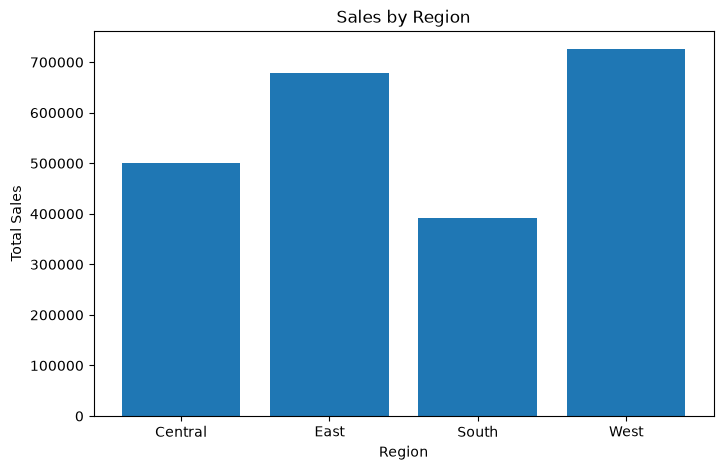

In [19]:
#sales by region bar chart
sales_region = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8,5))
plt.bar(sales_region.index, sales_region.values)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

In [20]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


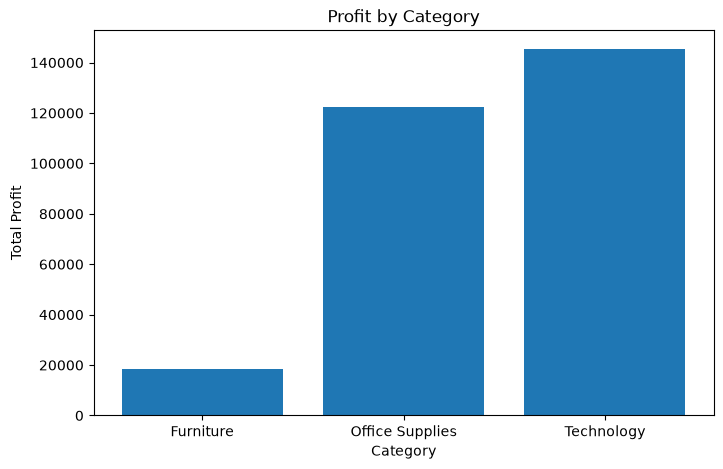

In [21]:
#profit by category
profit_category = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(8,5))
plt.bar(profit_category.index, profit_category.values)
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()

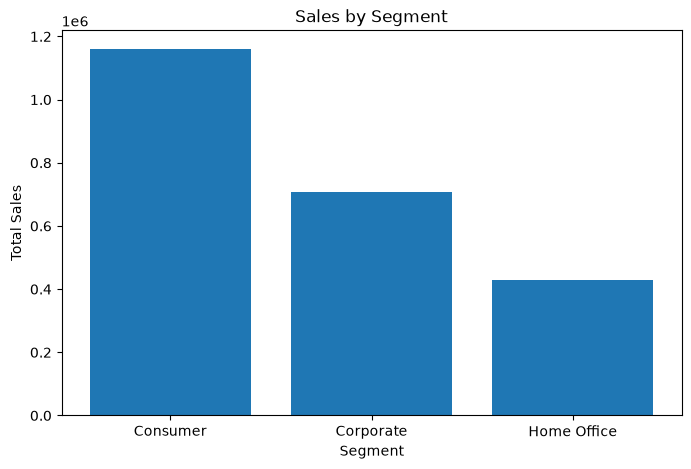

In [22]:
#sales by segment
sales_segment = df.groupby("Segment")["Sales"].sum()

plt.figure(figsize=(8,5))
plt.bar(sales_segment.index, sales_segment.values)
plt.title("Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.show()

In [23]:
df.to_csv("cleaned_superstore.csv", index=False)

print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!


In [24]:
df[["Sales", "Profit", "Quantity", "Discount"]].corr()

,Sales,Profit,Quantity,Discount
Sales,1.000000,0.479067,0.200722,-0.028311
Profit,0.479067,1.000000,0.066211,-0.219662
Quantity,0.200722,0.066211,1.000000,0.008678
Discount,-0.028311,-0.219662,0.008678,1.000000


In [25]:
top_states = (
    df.groupby("State")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_states)

State
California      457576.2715
New York        310827.1510
Texas           170124.5418
Washington      138560.8100
Pennsylvania    116496.3620
Florida          89473.7080
Illinois         80162.5370
Ohio             77976.7640
Michigan         75879.6440
Virginia         70636.7200
Name: Sales, dtype: float64


In [26]:
top_cities = (
    df.groupby("City")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_cities)

City
New York City    62013.8973
Los Angeles      30431.4267
Seattle          29121.6825
San Francisco    17466.1186
Detroit          13146.6935
Lafayette        10018.3876
Jackson           7581.6828
Atlanta           6993.6629
Minneapolis       6824.5846
San Diego         6377.1960
Name: Profit, dtype: float64


In [27]:
loss_orders = df[df["Profit"] < 0]

print("Number of Loss Orders:", len(loss_orders))
loss_orders.head()

Number of Loss Orders: 1869


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
14,Standard Class,Home Office,United States,Fort Worth,Texas,76106,Central,Office Supplies,Appliances,68.8100,5,0.80,-123.8580
15,Standard Class,Home Office,United States,Fort Worth,Texas,76106,Central,Office Supplies,Binders,2.5440,3,0.80,-3.8160
23,Second Class,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Furniture,Chairs,71.3720,2,0.30,-1.0196
27,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Furniture,Bookcases,3083.4300,7,0.50,-1665.0522


In [28]:
discount_sales = df.groupby("Discount")["Profit"].mean()

print(discount_sales)

Discount
0.00     67.024108
0.10     96.055074
0.15     27.288298
0.20     24.721217
0.30    -45.828401
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -102.116395
Name: Profit, dtype: float64


In [ ]:
# Exploratory Data Analysis (EDA)

## Objective
To explore the Sample Superstore dataset, identify trends, detect anomalies, and generate business insights.

## Data Cleaning
- Checked for missing values.
- Checked for duplicate records.
- Verified data types.
- Confirmed data quality before analysis.

## Key Insights
1. The West region generated the highest sales.
2. The Consumer segment contributed the highest revenue.
3. Technology and Office Supplies performed well in sales.
4. Some orders resulted in negative profit.
5. Higher discounts generally reduced profitability.

## Conclusion
The dataset was clean and suitable for analysis. The insights can help identify profitable regions, categories, and pricing strategies for better business decisions.